# **Delivery Performance Optimization:**

> **`Problem`**:   
The company needs to improve its on-time delivery performance to enhance customer satisfaction and competitive advantage.

> **`Key Questions`**:     
> - What is the current on-time delivery rate across different warehouse blocks?
> - Which factors most significantly impact delivery timeliness?
> - How can we predict which shipments are likely to be delayed?

> **`Business Impact`**:   
Poor delivery performance leads to customer dissatisfaction, negative reviews, and potential loss of business to competitors.

In [2]:
import pandas as pd 
import numpy as np 
import warnings as war 
war.filterwarnings("ignore")
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
data= pd.read_json("https://raw.githubusercontent.com/rajesh-coventry/Projects/refs/heads/master/02_Data_Visuallization/05_E-Commerce_Shipping/ecommerce_shipping_data.json")
data.shape

(10999, 12)

In [4]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


## **1. Data Exploration and Quality Assessment:**

In [5]:
# Descriptive statistics for numerical columns: 
data.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


**Outliers Detection:**

In [6]:
# Outliers Detection and save outliers in series for each column:
outliers = {}
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[col] = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index

In [7]:
data.select_dtypes(include=['int64', 'float64']).columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [ ]:
outliers["ID"], outliers["Customer_rating"], outliers["Customer_care_calls"], outliers["Cost_of_the_Product"], outliers["Weight_in_gms"], outliers["Reached.on.Time_Y.N"]

# These columns have no outlier values

(Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'))

Following two columns `'Prior_purchases'` and, `"Discount_offered"`  contains outlier values:

In [9]:
out1= outliers["Prior_purchases"]
out1= out1.to_frame(name= "out11")
out1.head(3)

,out11
37,37
62,62
74,74


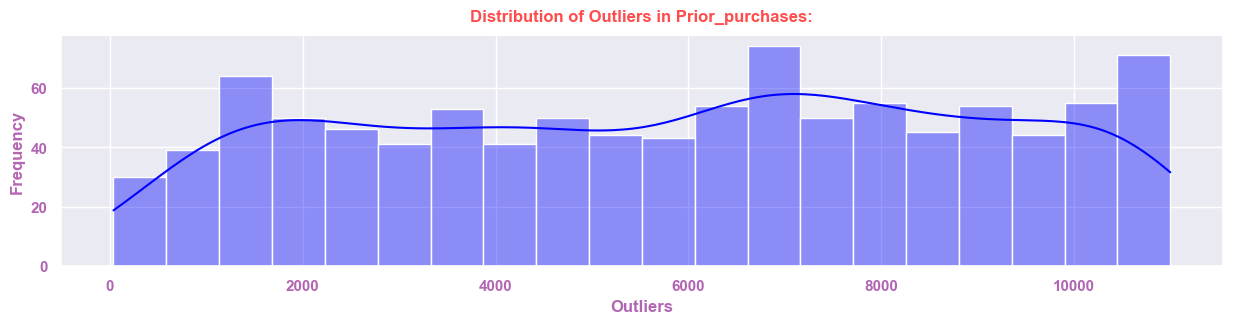

In [28]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="darkgrid")
sns.histplot(data=out1, x="out11", kde=True, bins=20, color= "blue", alpha=0.4)
plt.title("Distribution of Outliers in Prior_purchases:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Outliers", color="purple", fontweight="bold", alpha=0.6)
plt.ylabel("Frequency", color="purple", fontweight="bold", alpha=0.6)    
plt.xticks(alpha=0.6, color="purple", fontweight="bold")
plt.yticks(alpha=0.6, color="purple", fontweight="bold")
plt.show()

In [17]:
outliers["Discount_offered"]
out2= outliers["Discount_offered"].to_frame(name= "out22")
out2.head(3)

,out22
0,0
1,1
2,2


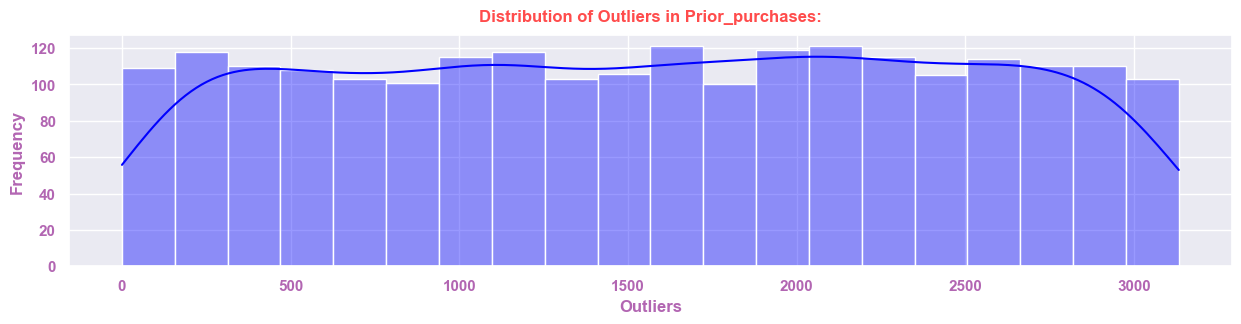

In [30]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="darkgrid")
sns.histplot(data=out2, x="out22", kde=True, bins=20, alpha= 0.4, color= "blue")
plt.title("Distribution of Outliers in Prior_purchases:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Outliers", color="purple", fontweight="bold", alpha=0.6)
plt.ylabel("Frequency", color="purple", fontweight="bold", alpha=0.6)    
plt.xticks(alpha=0.6, color="purple", fontweight="bold")
plt.yticks(alpha=0.6, color="purple", fontweight="bold")
plt.show()

**Box plots for the distribution of all numeric columns:**

In [55]:
data.select_dtypes(include=['int64', 'float64']).columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

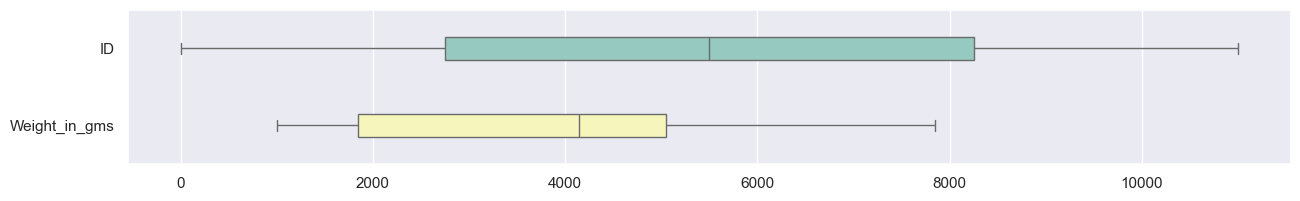

In [68]:
# Box plot for the distribution of all numeric columns:
plt.figure(figsize=(15, 2))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[["ID", "Weight_in_gms"]], orient="h", palette="Set3", width= 0.3)
plt.show()

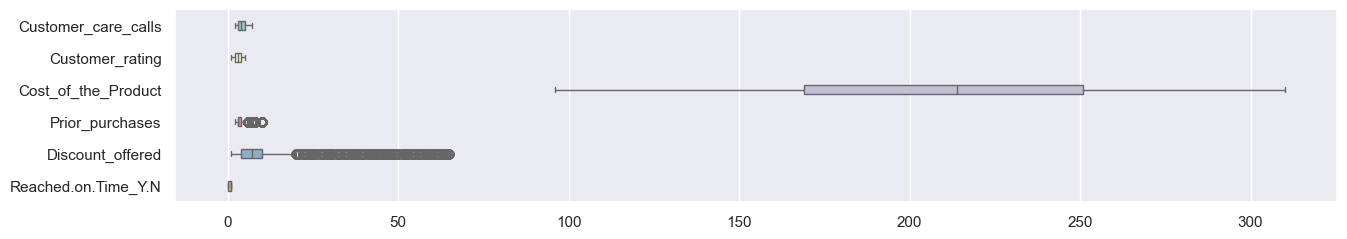

In [63]:
plt.figure(figsize=(15, 2.5))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered',
       'Reached.on.Time_Y.N']], orient="h", palette="Set3", width= 0.3)
plt.show()

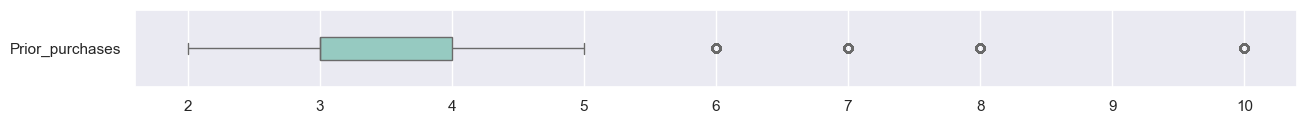

In [66]:
plt.figure(figsize=(15, 1))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Prior_purchases']], orient="h", palette="Set3", width= 0.3)
plt.show()

<Axes: >

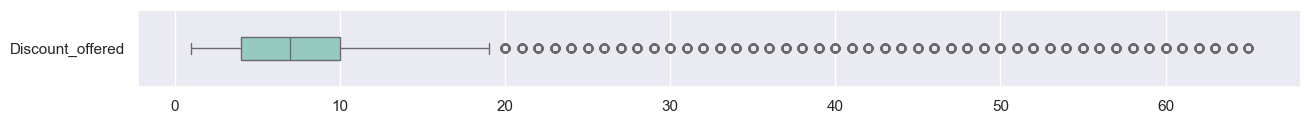

In [67]:
plt.figure(figsize=(15, 1))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Discount_offered']], orient="h", palette="Set3", width= 0.3)

-----
-----
-----
-----
---

## **2. Overall Delivery Performance Baseline:**

In [69]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [71]:
data["Reached.on.Time_Y.N"].value_counts().reset_index()

,Reached.on.Time_Y.N,count
0,1,6563
1,0,4436


In [ ]:
current_on_time_delivery_rate= round((data["Reached.on.Time_Y.N"].value_counts().reset_index().loc[0, "count"] / data.shape[0]) * 100, 2)
print(F'Current on-time Delivery Rate is: {current_on_time_delivery_rate}') 

Current on-time Delivery Rate is: 59.67


Current on-time delivery rate is about 60%.

In [79]:
# Summary statistics for on-time deliveries:
data[data["Reached.on.Time_Y.N"]== 1].describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,6563.000000,6563.000000,6563.000000,6563.000000,6563.000000,6563.000000,6563.000000,6563.0
mean,4424.978364,3.991467,3.005790,207.289197,3.498095,18.663721,3272.640104,1.0
std,3243.986559,1.122592,1.412692,48.054876,1.517285,19.108797,1576.148391,0.0
min,1.000000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,1.0
25%,1641.500000,3.000000,2.000000,167.000000,3.000000,5.000000,1735.500000,1.0
50%,3467.000000,4.000000,3.000000,209.000000,3.000000,9.000000,3231.000000,1.0
75%,7194.500000,5.000000,4.000000,249.000000,4.000000,32.000000,4696.500000,1.0
max,10995.000000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.0


* Customers make about 4 customer care calls on average.

* Average customer rating is roughly 3 out of 5.
* Mean product cost is around 207 units.
* Customers typically make 3 to 4 prior purchases.
* Average discount offered is nearly $18.66.
* Products weigh about 3273 grams on average.
* All deliveries reached on time (mean is 1.0).

In [83]:
data.sample(10)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
6888,6889,D,Ship,7,3,309,4,low,F,1,1290,1
595,596,F,Ship,3,1,185,3,low,M,61,3280,1
10293,10294,B,Ship,2,4,144,2,medium,M,5,5867,0
4953,4954,B,Ship,3,3,181,3,medium,F,3,5620,1
855,856,B,Ship,3,2,139,2,low,M,63,1767,1
2202,2203,D,Flight,5,3,266,3,low,F,19,2508,1
6157,6158,F,Road,3,4,233,3,medium,M,5,5306,0
10544,10545,A,Flight,4,1,195,2,low,F,3,4165,0
6076,6077,C,Ship,3,4,188,4,low,F,6,5016,0
8881,8882,F,Road,6,1,256,4,low,F,7,1372,1


In [84]:
# Summary statistics for off-time deliveries:
data[data["Reached.on.Time_Y.N"]== 0].describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,4436.000000,4436.000000,4436.000000,4436.000000,4436.000000,4436.000000,4436.000000,4436.0
mean,7090.479486,4.147656,2.967989,214.498647,3.670424,5.545987,4168.668395,0.0
std,2278.543555,1.162771,1.414808,47.757432,1.525444,2.877727,1573.954178,0.0
min,3136.000000,2.000000,1.000000,97.000000,2.000000,1.000000,1001.000000,0.0
25%,5092.250000,3.000000,2.000000,174.000000,3.000000,3.000000,4043.500000,0.0
50%,7096.000000,4.000000,3.000000,222.000000,3.000000,6.000000,4674.000000,0.0
75%,9078.500000,5.000000,4.000000,254.000000,4.000000,8.000000,5337.000000,0.0
max,10999.000000,7.000000,5.000000,310.000000,10.000000,10.000000,6000.000000,0.0


* Customers made about 4.15 calls on average.

* Average customer rating is approximately 3 out of 5.
* Product cost averages around 214 units.
* Customers made nearly 3.7 prior purchases.
* Average discount offered is about $5.5.
* Product weight averages around 4169 grams.
* On average, delivery was **`not on time`** ($Reached.on.Time\_Y.N = 0$).

----
---
---
---
----
----
---

## **3. Warehouse Block Performance Analysis:**

**What we do**: Compare on-time delivery rates across different warehouse blocks to identify best and worst performing facilities.

**Implementation approach**: Group data by 'Warehouse_block', calculate delivery rates for each block, create comparative bar charts using matplotlib/seaborn, and perform statistical significance tests to identify meaningful differences between warehouses.

In [86]:
data.columns 

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [89]:
# Warehouse and shipments from each of the house:
nan= data["Warehouse_block"].value_counts()
nan

Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

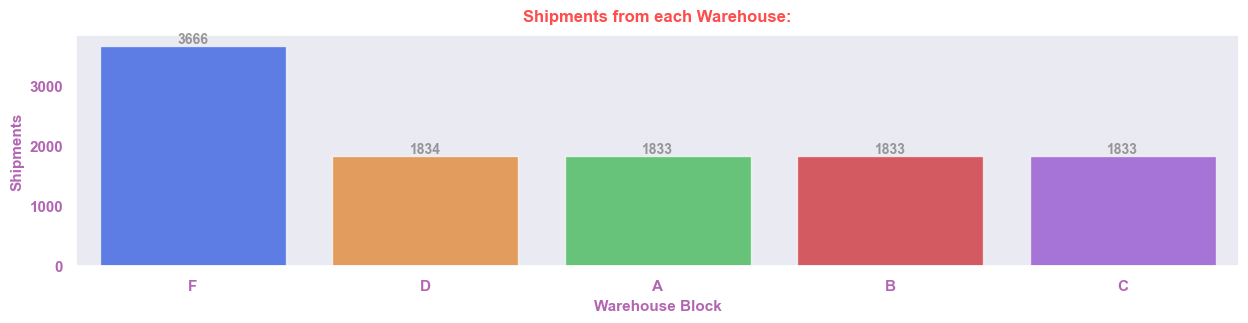

In [115]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="dark")
sns.barplot(x= nan.index, y= nan.values, palette="bright", alpha= 0.7)
plt.title("Shipments from each Warehouse:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7) 
plt.xlabel("Warehouse Block", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.ylabel("Shipments", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.xticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11) 
plt.yticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
# add annotations to the bars
for i, v in enumerate(nan.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontweight='bold', fontsize= 10, color="gray", alpha=0.8)
plt.show()

In [117]:
rat= data.groupby("Warehouse_block")["Reached.on.Time_Y.N"].value_counts().reset_index(name= "count")
rat

,Warehouse_block,Reached.on.Time_Y.N,count
0,A,1,1075
1,A,0,758
2,B,1,1104
3,B,0,729
4,C,1,1094
5,C,0,739
6,D,1,1096
7,D,0,738
8,F,1,2194
9,F,0,1472


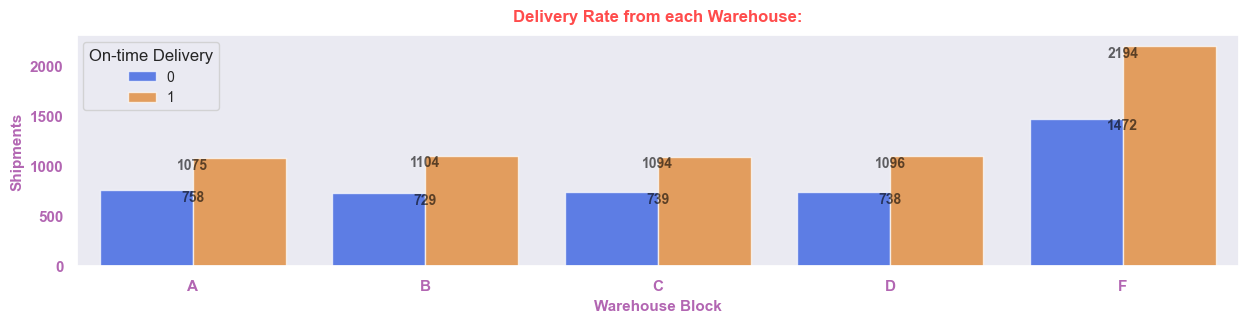

In [139]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="dark")
sns.barplot(x= rat["Warehouse_block"], y= rat["count"], hue= rat["Reached.on.Time_Y.N"], palette="bright", alpha= 0.7)
plt.title("Delivery Rate from each Warehouse:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Warehouse Block", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.ylabel("Shipments", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.xticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.yticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.legend(title= "On-time Delivery", loc= "upper left", fontsize= 10)

# Add annotations for each bar group
for i in range(len(rat["Warehouse_block"].unique())):
    for j in range(len(rat["Reached.on.Time_Y.N"].unique())):
        index = i * len(rat["Reached.on.Time_Y.N"].unique()) + j
        value = rat.iloc[index]["count"]
        plt.text(i, value, str(value), ha='center', va='top', fontweight='bold', fontsize=10, color="black", alpha=0.6)

plt.show()

In [140]:
# compute the propersion of on-time deliveries for each warehouse block
rat["proportion"] = rat.groupby("Warehouse_block")["count"].transform(lambda x: x / x.sum())

In [141]:
rat

,Warehouse_block,Reached.on.Time_Y.N,count,delivery_rate,proportion
0,A,1,1075,NaN,0.586470
1,A,0,758,NaN,0.413530
2,B,1,1104,NaN,0.602291
3,B,0,729,NaN,0.397709
4,C,1,1094,NaN,0.596836
5,C,0,739,NaN,0.403164
6,D,1,1096,NaN,0.597601
7,D,0,738,NaN,0.402399
8,F,1,2194,NaN,0.598472
9,F,0,1472,NaN,0.401528


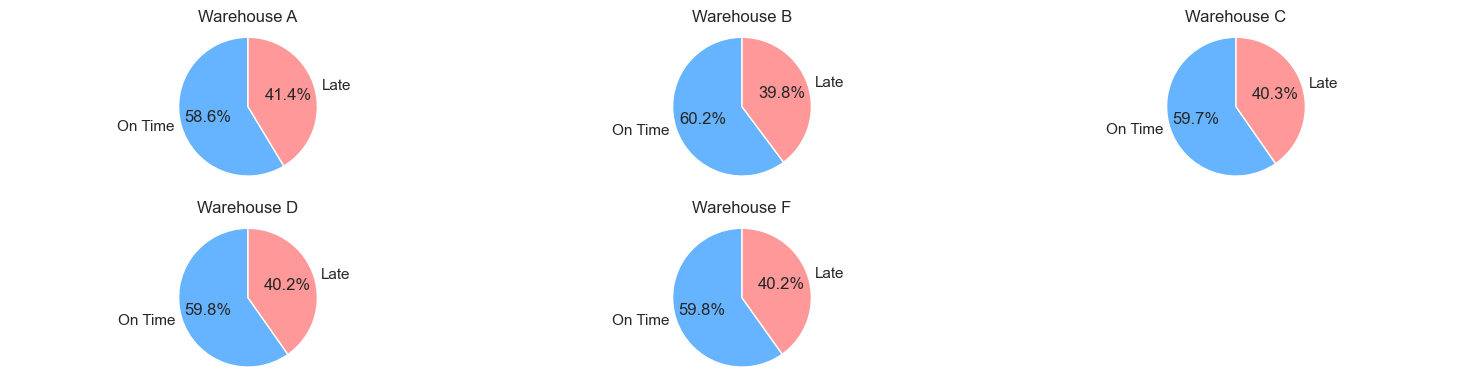

In [150]:
import math 
# Get unique warehouses
warehouses = rat['Warehouse_block'].unique()
n_warehouses = len(warehouses)

# Subplot grid dimensions
n_cols = 3
n_rows = math.ceil(n_warehouses / n_cols)

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 2))
axes = axes.flatten()  # Flatten in case of single row

# Loop through each warehouse and plot
for i, block in enumerate(warehouses):
    subset = rat[rat['Warehouse_block'] == block]
    sizes = subset['count'].values
    labels = ['On Time', 'Late']
    colors = ['#66b3ff', '#ff9999']

    axes[i].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'Warehouse {block}')
    axes[i].axis('equal')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

* **`Warehouse A`**: 58.6% deliveries were on time, 41.4% were late

* **`Warehouse B`**: Has the highest on-time rate at 60.2%
* **`Warehouse C`**: 59.7% on-time; slightly better than Warehouse A
* **`Warehouse D`**: Same on-time rate as Warehouse C at 59.8%
* **`Warehouse F`**: Also 59.8% on-time, equal to Warehouse D
* **`All warehouses`**: On-time delivery rate is consistently around 59–60%
* **`Late deliveries`**: Range from 39.8% to 41.4% across all warehouses
* **`Warehouse A`**: Has the highest late delivery rate among all
* **`Warehouse B`**: Most efficient in terms of timely deliveries

**Perform statistical significance tests to identify meaningful differences between warehouses:**